# Results Display


In [9]:
from pathlib import Path

DATASET_PATH = r"C:\Users\Admin\Downloads\riva_1.0"

BASE_DIR = Path(DATASET_PATH)
IMG_DIR = BASE_DIR / "images"
OUTPUT_ROOT = BASE_DIR.parent / "riva_outputs"
MODEL_DIR_PATH = OUTPUT_ROOT / "saved_models"
RESULTS_DIR_PATH = OUTPUT_ROOT / "results"
FIG_DIR_PATH = OUTPUT_ROOT / "figures"
CACHE_DIR_PATH = OUTPUT_ROOT / "cache"

for folder in [MODEL_DIR_PATH, RESULTS_DIR_PATH, FIG_DIR_PATH, CACHE_DIR_PATH]:
    folder.mkdir(parents=True, exist_ok=True)


In [10]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_latest_result(pattern):
    files = sorted(RESULTS_DIR_PATH.glob(pattern))
    if not files:
        return None, None

    path = files[-1]
    with open(path, "r", encoding="utf-8") as file:
        return json.load(file), path

binary_results, binary_path = load_latest_result("binary_results_*.json")
multiclass_6_results, multiclass_6_path = load_latest_result("multiclass_6class_results_*.json")
multiclass_7_results, multiclass_7_path = load_latest_result("multiclass_7class_results_*.json")
multiclass_8_results, multiclass_8_path = load_latest_result("multiclass_8class_results_*.json")
localisation_results, localisation_path = load_latest_result("localisation_results_*.json")

print("Binary:", binary_path)
print("Six-class:", multiclass_6_path)
print("Seven-class:", multiclass_7_path)
print("Eight-class:", multiclass_8_path)
print("Localisation:", localisation_path)


Binary: C:\Users\Admin\Downloads\riva_outputs\results\binary_results_20260627_203810.json
Six-class: C:\Users\Admin\Downloads\riva_outputs\results\multiclass_6class_results_20260628_222014.json
Seven-class: C:\Users\Admin\Downloads\riva_outputs\results\multiclass_7class_results_20260629_051847.json
Eight-class: C:\Users\Admin\Downloads\riva_outputs\results\multiclass_8class_results_20260629_095501.json
Localisation: C:\Users\Admin\Downloads\riva_outputs\results\localisation_results_20260614_180310.json


## Classification comparison


,task,model,precision,recall,f1,average_precision,high_risk_recall
0,Binary,CNN,0.862069,0.268817,0.409836,None,None
1,Binary,ResNet34,0.877193,0.537634,0.666667,None,None
2,Binary,EfficientNet,0.765957,0.774194,0.770053,None,None
3,Six-class,CNN,0.015873,0.166667,0.028986,None,None
4,Six-class,ResNet34,0.268278,0.245092,0.250331,None,None
5,Six-class,EfficientNet,0.306295,0.293540,0.292584,None,None
6,Seven-class,CNN,0.003348,0.142857,0.006543,None,None
7,Seven-class,ResNet34,0.452134,0.334375,0.336143,None,None
8,Seven-class,EfficientNet,0.274603,0.258736,0.235100,None,None
9,Eight-class,CNN,0.083993,0.145833,0.049387,None,None


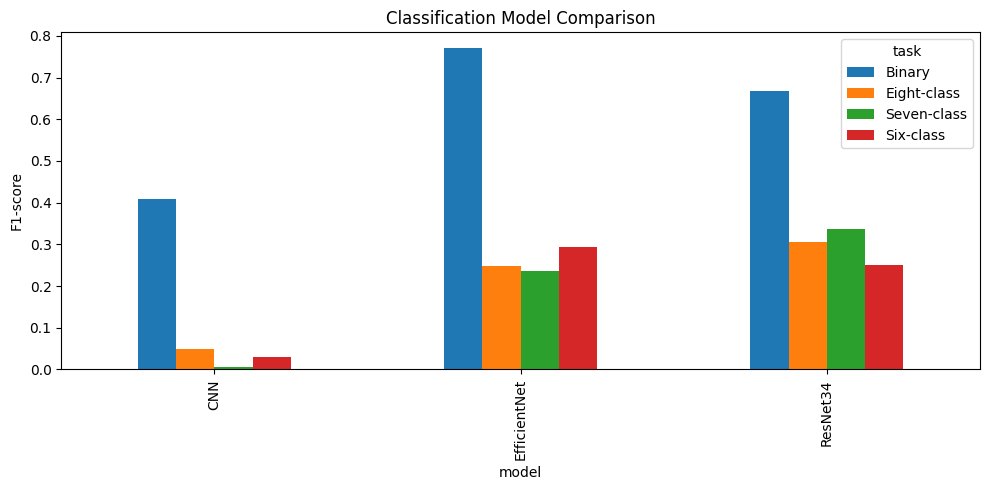

In [15]:
classification_rows = []

if binary_results is not None:
    for model_name, metrics in binary_results.get("results", {}).items():
        classification_rows.append({
            "task": "Binary",
            "model": model_name,
            "precision": metrics.get("precision"),
            "recall": metrics.get("recall"),
            "f1": metrics.get("f1"),
            "average_precision": metrics.get("average_precision"),
            "high_risk_recall": metrics.get("high_risk_recall"),
        })

for task_name, result_payload in [
    ("Six-class", multiclass_6_results),
    ("Seven-class", multiclass_7_results),
    ("Eight-class", multiclass_8_results),
]:
    if result_payload is None:
        continue

    for model_name, metrics in result_payload.get("results", {}).items():
        classification_rows.append({
            "task": task_name,
            "model": model_name,
            "precision": metrics.get("precision", metrics.get("precision_macro")),
            "recall": metrics.get("recall", metrics.get("recall_macro")),
            "f1": metrics.get("f1", metrics.get("f1_macro")),
            "average_precision": metrics.get("average_precision"),
            "high_risk_recall": metrics.get("high_risk_recall"),
        })

classification_table = pd.DataFrame(classification_rows)
display(classification_table)

if not classification_table.empty:
    classification_table.pivot_table(
        index="model",
        columns="task",
        values="f1",
    ).plot(kind="bar", figsize=(10, 5))

    plt.ylabel("F1-score")
    plt.title("Classification Model Comparison")
    plt.tight_layout()
    plt.savefig(FIG_DIR_PATH / "classification_f1_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

## Localisation comparison


,model,threshold,pixel_precision,pixel_recall,pixel_f1,dice,iou,global_pixel_average_precision,mean_pixel_average_precision,keypoint_precision,keypoint_recall,keypoint_f1,pck,mean_matched_distance,matched_keypoints,false_positive_keypoints,missed_keypoints,distance_threshold_pixels,training_minutes
0,Integrated U-Net,0.1,0.130225,0.160773,0.143895,0.367699,0.354713,0.061881,0.150604,0.128995,0.110893,0.119261,0.110893,5.180801,113,763,906,12.0,21.794619
1,Integrated Stacked Hourglass,0.1,0.000000,0.000000,0.000000,0.354167,0.354167,0.009268,0.027087,0.000000,0.000000,0.000000,0.000000,NaN,0,0,1019,12.0,14.921264


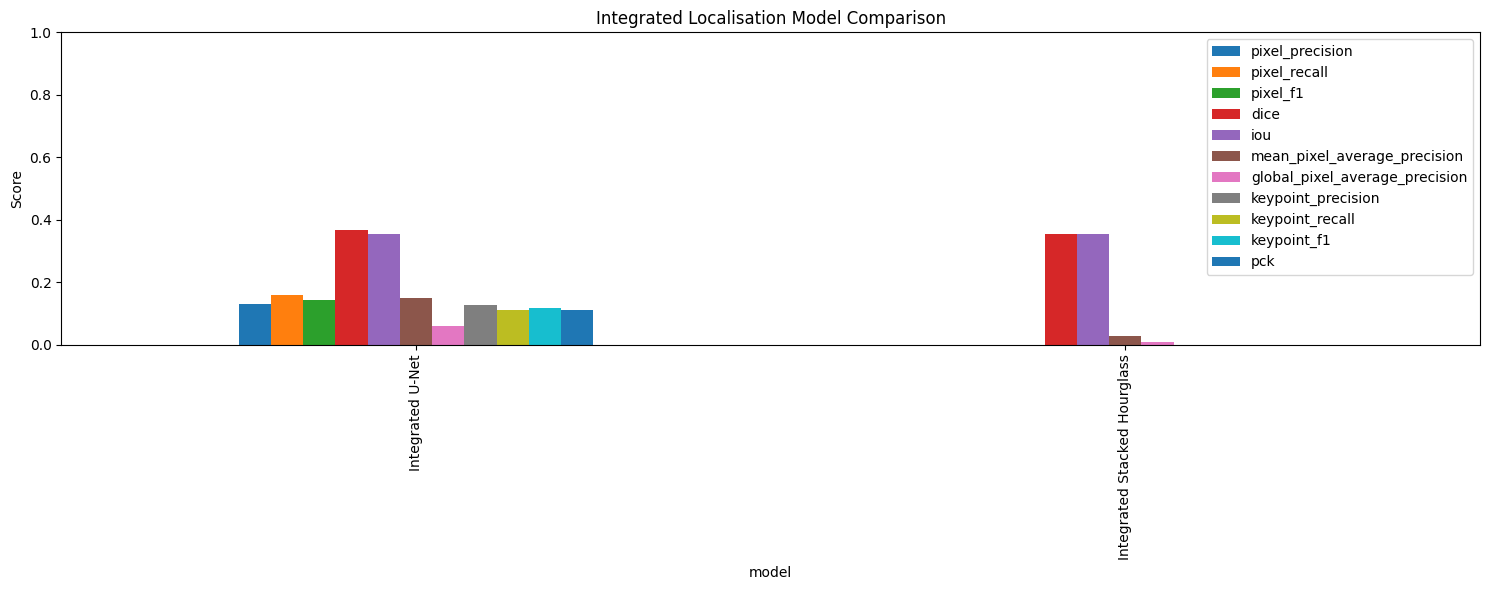

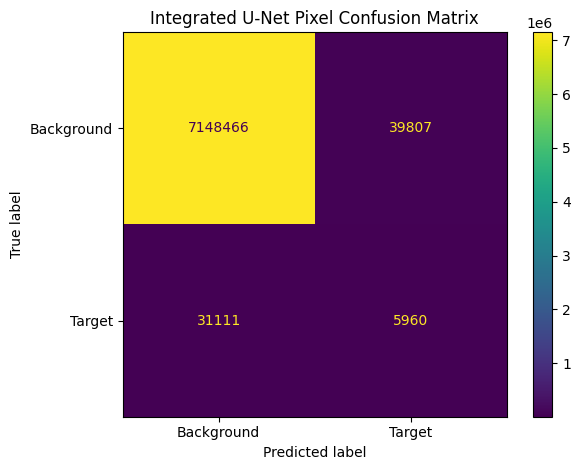

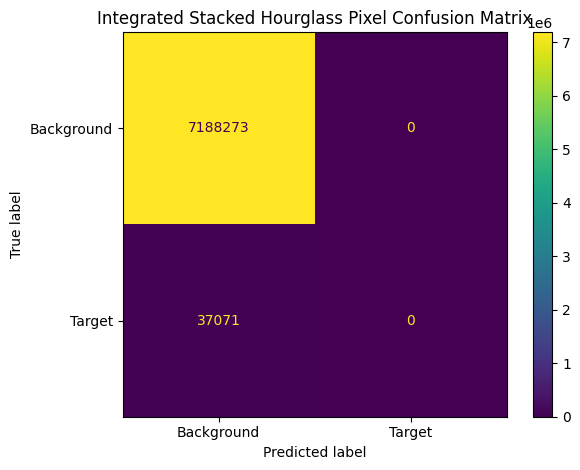

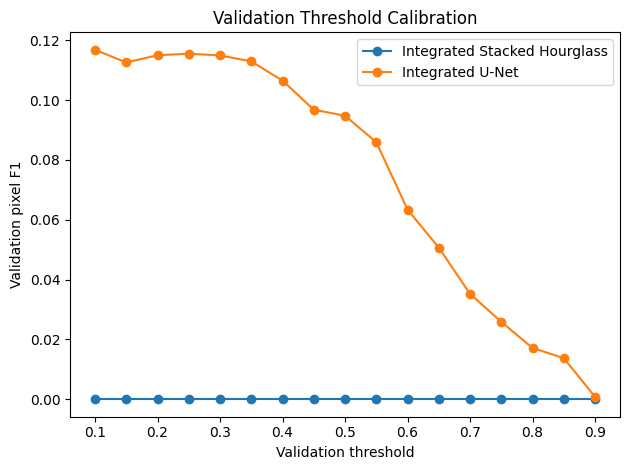

In [12]:
if localisation_results is None:
    print("Run localisation.ipynb before this section.")
else:
    localisation_rows = []

    for model_name, key in [
        ("Integrated U-Net", "unet"),
        ("Integrated Stacked Hourglass", "hourglass"),
    ]:
        model_data = localisation_results[key]
        localisation_rows.append({
            "model": model_name,
            **model_data["metrics"],
            "training_minutes": model_data.get("training_minutes"),
        })

    localisation_table = pd.DataFrame(localisation_rows)
    display(localisation_table.drop(columns=["pixel_confusion_matrix"], errors="ignore"))

    metric_columns = [
        "pixel_precision", "pixel_recall", "pixel_f1", "dice", "iou",
        "mean_pixel_average_precision", "global_pixel_average_precision",
        "keypoint_precision", "keypoint_recall", "keypoint_f1", "pck",
    ]
    available_columns = [column for column in metric_columns if column in localisation_table.columns]

    localisation_table.set_index("model")[available_columns].plot(kind="bar", figsize=(15, 6))
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.title("Integrated Localisation Model Comparison")
    plt.tight_layout()
    plt.savefig(FIG_DIR_PATH / "localisation_metric_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    for row in localisation_rows:
        matrix = np.asarray(row.get("pixel_confusion_matrix", [[0, 0], [0, 0]]))
        display_object = ConfusionMatrixDisplay(matrix, display_labels=["Background", "Target"])
        display_object.plot(values_format="d")
        plt.title(f"{row['model']} Pixel Confusion Matrix")
        plt.tight_layout()
        plt.savefig(
            FIG_DIR_PATH / f"{row['model'].lower().replace(' ', '_')}_pixel_confusion_matrix.png",
            dpi=150, bbox_inches="tight"
        )
        plt.show()

    threshold_frames = []
    for model_name, key in [("Integrated U-Net", "unet"), ("Integrated Stacked Hourglass", "hourglass")]:
        for row in localisation_results[key].get("threshold_rows", []):
            threshold_frames.append({"model": model_name, **row})
    threshold_table = pd.DataFrame(threshold_frames)
    if not threshold_table.empty:
        for model_name, group in threshold_table.groupby("model"):
            plt.plot(group["threshold"], group["pixel_f1"], marker="o", label=model_name)
        plt.xlabel("Validation threshold")
        plt.ylabel("Validation pixel F1")
        plt.title("Validation Threshold Calibration")
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR_PATH / "localisation_threshold_calibration.png", dpi=150, bbox_inches="tight")
        plt.show()


### Localisation metric terminology

For thesis reporting, use **pixel-wise heatmap average precision** for `global_pixel_average_precision` and `mean_pixel_average_precision`. Do not shorten these values to conventional “mAP”. Use the keypoint metrics separately when discussing how accurately individual abnormal cells were located.


## Best binary classifier


In [13]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))

class ResNetModel(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.backbone = models.resnet34(weights=None)
        feature_count = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_count, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)

class EfficientNetModel(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=None)
        feature_count = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_count, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)

MODEL_REGISTRY = {
    "CNN": SimpleCNN,
    "ResNet34": ResNetModel,
    "EfficientNet": EfficientNetModel,
}

def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)

checkpoint_path = MODEL_DIR_PATH / "riva_binary_best.pth"

if not checkpoint_path.exists():
    raise FileNotFoundError("Run classification.ipynb before results.ipynb.")

checkpoint = safe_torch_load(checkpoint_path, device)
classifier_name = checkpoint["model_architecture"]
classifier_configuration = checkpoint.get("best_cfg", {})
class_names = checkpoint.get("class_names", ["NON_LESION", "PRECANCEROUS"])
positive_index = class_names.index("PRECANCEROUS")

classifier = MODEL_REGISTRY[classifier_name](
    num_classes=len(class_names),
    dropout=classifier_configuration.get("dropout", 0.3),
)
classifier.load_state_dict(checkpoint["model_state_dict"], strict=True)
classifier.to(device)
classifier.eval()

print("Best binary classifier:", classifier_name)


Best binary classifier: EfficientNet


## Grad-CAM


IndexError: index 1 is out of bounds for dimension 0 with size 1

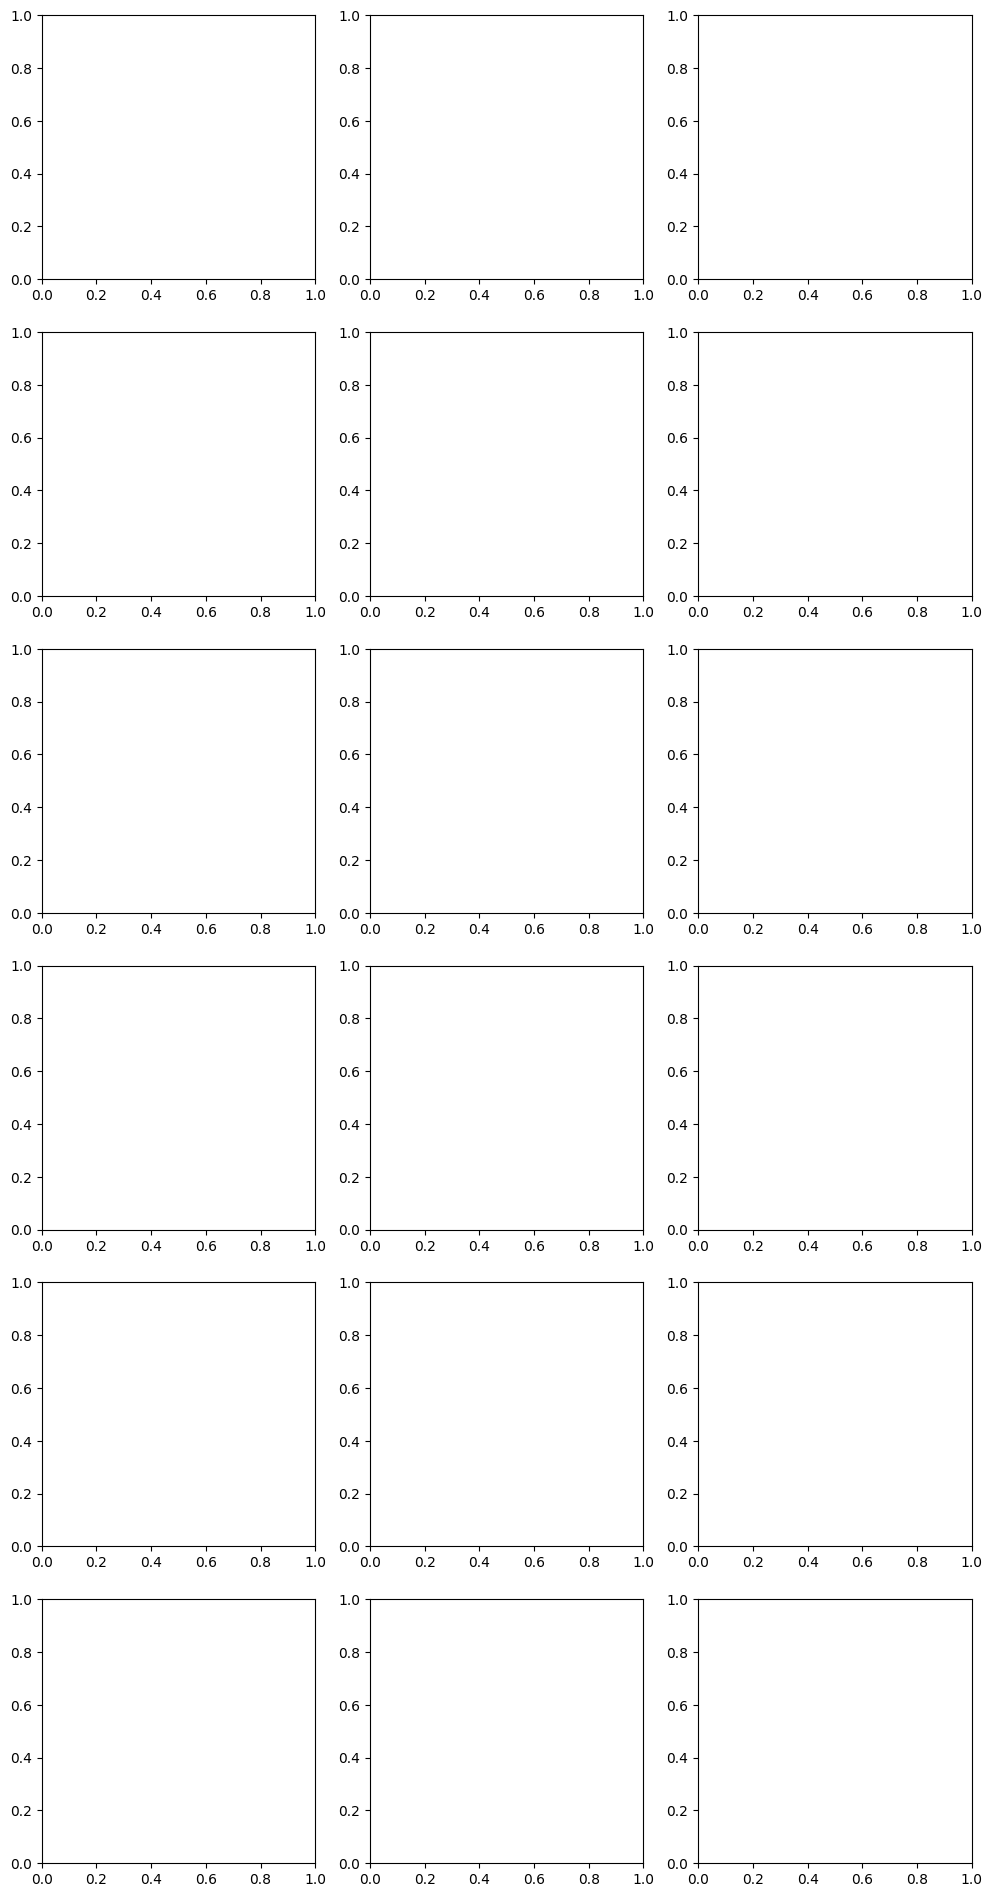

In [14]:
def find_last_convolution(model):
    convolution_layers = [module for module in model.modules() if isinstance(module, nn.Conv2d)]
    if not convolution_layers:
        raise ValueError("No convolutional layer was found.")
    return convolution_layers[-1]

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output

    def _backward_hook(self, module, gradient_input, gradient_output):
        self.gradients = gradient_output[0]

    def generate(self, input_tensor, class_index):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(input_tensor)
        logits[ class_index].sum().backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        heatmap = (weights * self.activations).sum(dim=1, keepdim=True)
        heatmap = F.relu(heatmap)
        heatmap = F.interpolate(heatmap, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        heatmap = heatmap[0, 0]
        heatmap = heatmap - heatmap.min()
        heatmap = heatmap / (heatmap.max() + 1e-8)
        return heatmap.detach().cpu().numpy(), logits.detach()

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

cache_path = CACHE_DIR_PATH / "localisation_test_predictions.npz"
selected_case_indices = []
selected_case_labels = []

if cache_path.exists():
    cache = np.load(cache_path, allow_pickle=True)
    cached_images = cache["images"]
    cached_targets = cache["class_targets"].astype(int)
    cached_probabilities = cache["classifier_probabilities"]
    cached_names = cache["image_names"]
    cached_predictions = (cached_probabilities >= 0.5).astype(int)

    case_masks = {
        "True positive": (cached_targets == 1) & (cached_predictions == 1),
        "True negative": (cached_targets == 0) & (cached_predictions == 0),
        "False positive": (cached_targets == 0) & (cached_predictions == 1),
        "False negative": (cached_targets == 1) & (cached_predictions == 0),
    }
    for label, mask in case_masks.items():
        indices = np.where(mask)[0]
        if len(indices):
            selected_case_indices.append(int(indices[0]))
            selected_case_labels.append(label)

    # Fill remaining slots with the most uncertain test cases.
    uncertainty_order = np.argsort(np.abs(cached_probabilities - 0.5))
    for index in uncertainty_order:
        if int(index) not in selected_case_indices:
            selected_case_indices.append(int(index))
            selected_case_labels.append("Uncertain case")
        if len(selected_case_indices) >= 6:
            break

    gradcam = GradCAM(classifier, find_last_convolution(classifier))
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    figure, axes = plt.subplots(len(selected_case_indices), 3, figsize=(12, 4 * len(selected_case_indices)))
    if len(selected_case_indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_index, (cache_index, case_label) in enumerate(zip(selected_case_indices, selected_case_labels)):
        image_array = np.transpose(cached_images[cache_index], (1, 2, 0))
        input_tensor = ((torch.tensor(cached_images[cache_index]) - mean) / std).unsqueeze(0).to(device)
        heatmap, logits = gradcam.generate(input_tensor, positive_index)
        probabilities = torch.sigmoid(logits)[0].cpu().numpy()

        axes[row_index, 0].imshow(image_array)
        axes[row_index, 0].set_title(f"{case_label}: {cached_names[cache_index]}")
        axes[row_index, 0].axis("off")

        axes[row_index, 1].imshow(image_array)
        axes[row_index, 1].imshow(heatmap, alpha=0.45)
        axes[row_index, 1].set_title(f"Grad-CAM, positive probability={probabilities[positive_index]:.3f}")
        axes[row_index, 1].axis("off")

        axes[row_index, 2].bar(class_names, probabilities)
        axes[row_index, 2].set_ylim(0, 1)
        axes[row_index, 2].set_title("Predicted probabilities")
        axes[row_index, 2].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.savefig(FIG_DIR_PATH / "gradcam_error_case_examples.png", dpi=150, bbox_inches="tight")
    plt.show()
    gradcam.close()
else:
    print("Run the corrected localisation notebook to create the full test cache.")


## Classifier feature maps


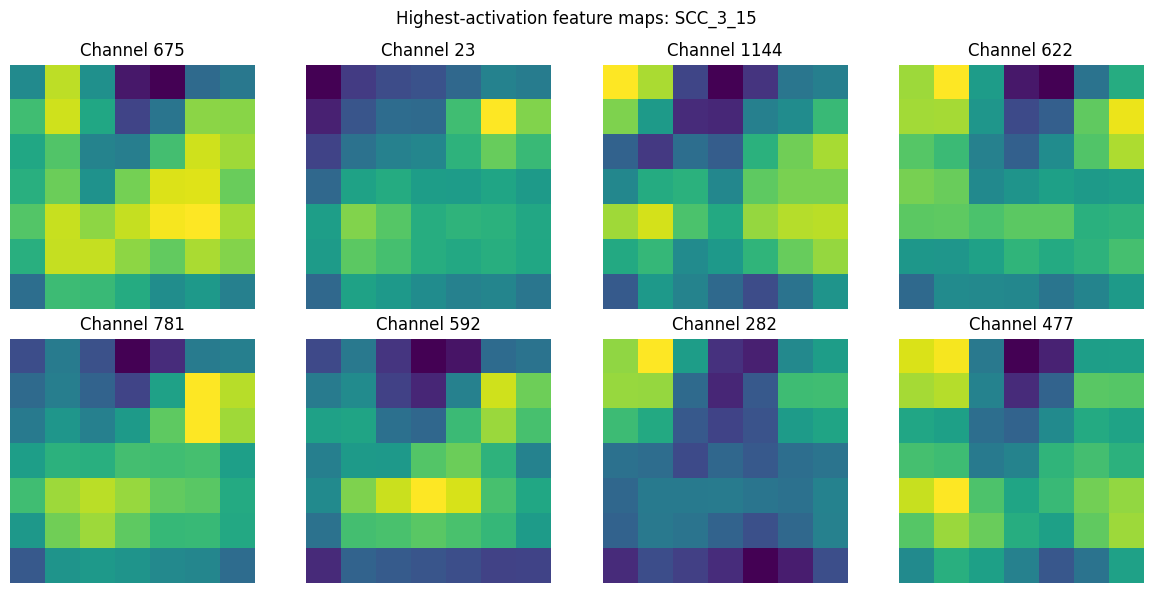

In [ ]:
captured_features = {}

def feature_hook(module, inputs, output):
    captured_features["value"] = output.detach().cpu()

feature_layer = find_last_convolution(classifier)
handle = feature_layer.register_forward_hook(feature_hook)

if cache_path.exists() and selected_case_indices:
    cache_index = selected_case_indices[0]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    input_tensor = ((torch.tensor(cached_images[cache_index]) - mean) / std).unsqueeze(0).to(device)

    with torch.no_grad():
        classifier(input_tensor)

    feature_tensor = captured_features["value"][0]
    channel_strength = feature_tensor.abs().mean(dim=(1, 2))
    selected_channels = torch.topk(channel_strength, k=min(8, feature_tensor.shape[0])).indices

    figure, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()
    for axis, channel_index in zip(axes, selected_channels):
        axis.imshow(feature_tensor[channel_index].numpy())
        axis.set_title(f"Channel {int(channel_index)}")
        axis.axis("off")

    plt.suptitle(f"Highest-activation feature maps: {cached_names[cache_index]}")
    plt.tight_layout()
    plt.savefig(FIG_DIR_PATH / "classifier_feature_maps.png", dpi=150, bbox_inches="tight")
    plt.show()

handle.remove()


## Localisation overlays and error analysis


,index,image_name,unet_dice,hourglass_dice,difference
80,80,LSIL_1_5,4.231909e-11,1.000000e+00,-1.000000e+00
48,48,SCC_4_6,1.569859e-10,1.000000e+00,-1.000000e+00
112,112,LSIL_11_2,1.818182e-10,1.000000e+00,-1.000000e+00
126,126,HSIL_9_19,3.537319e-11,3.389831e-10,-3.036099e-10
6,6,SCC_4_7,6.609385e-11,1.904762e-10,-1.243823e-10
...,...,...,...,...,...
68,68,SCC_2_3,3.749020e-01,1.788909e-10,3.749020e-01
36,36,SCC_5_23,4.151820e-01,2.881844e-10,4.151820e-01
123,123,HSIL_17_5,4.812261e-01,1.381215e-10,4.812261e-01
93,93,SCC_5_20,4.831612e-01,1.736111e-10,4.831612e-01


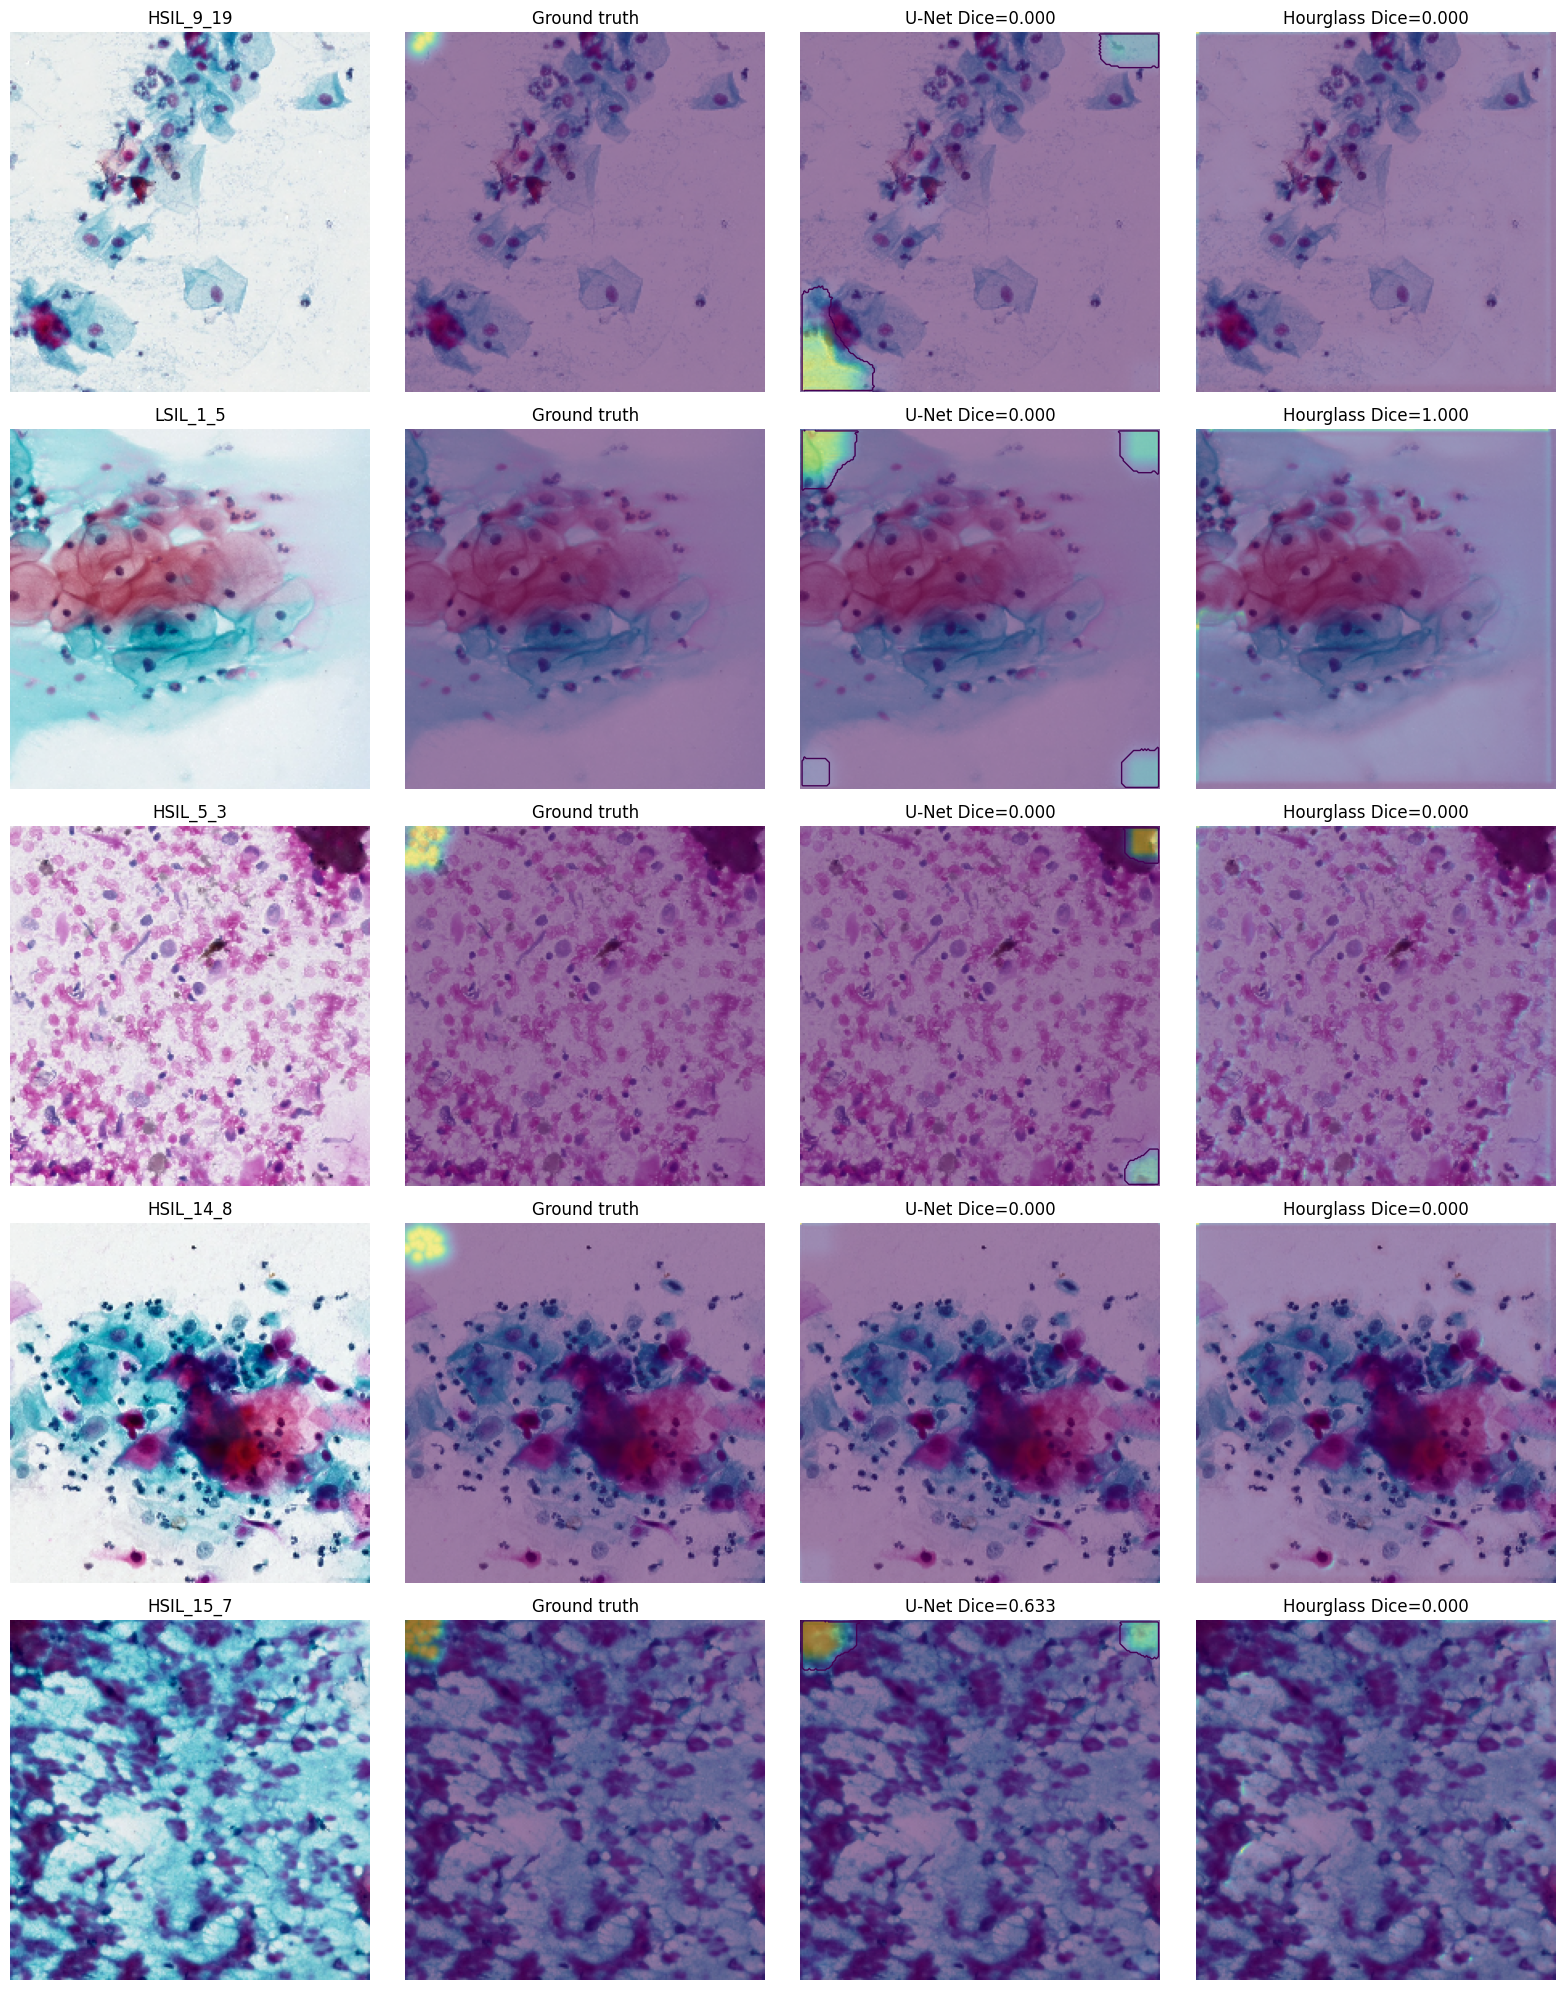

Lowest U-Net Dice scores across the complete test set


,index,image_name,unet_dice,hourglass_dice,difference
126,126,HSIL_9_19,3.537319e-11,3.389831e-10,-3.036099e-10
80,80,LSIL_1_5,4.231909e-11,1.000000e+00,-1.000000e+00
86,86,HSIL_14_4,5.205622e-11,1.569859e-10,-1.049297e-10
21,21,HSIL_9_15,5.299417e-11,1.567398e-10,-1.037456e-10
118,118,HSIL_5_3,6.321113e-11,1.283697e-10,-6.515858e-11


Lowest Hourglass Dice scores across the complete test set


,index,image_name,unet_dice,hourglass_dice,difference
118,118,HSIL_5_3,6.321113e-11,1.283697e-10,-6.515858e-11
53,53,HSIL_14_8,1.377410e-10,1.377410e-10,0.000000e+00
123,123,HSIL_17_5,4.812261e-01,1.381215e-10,4.812261e-01
61,61,HSIL_15_12,6.910850e-11,1.396648e-10,-7.055630e-11
134,134,LSIL_6_1,1.408451e-10,1.408451e-10,0.000000e+00


In [ ]:
example_path = CACHE_DIR_PATH / "localisation_test_predictions.npz"

if not example_path.exists():
    print("Run the corrected localisation notebook before this section.")
else:
    examples = np.load(example_path, allow_pickle=True)
    images = examples["images"]
    targets = examples["targets"]
    unet_predictions = examples["unet_predictions"]
    hourglass_predictions = examples["hourglass_predictions"]
    image_names = examples["image_names"]
    unet_threshold = float(examples["unet_threshold"][0])
    hourglass_threshold = float(examples["hourglass_threshold"][0])

    def per_image_dice(prediction, target, threshold):
        prediction_binary = prediction >= threshold
        target_binary = target >= 0.25
        intersection = np.logical_and(prediction_binary, target_binary).sum()
        return (2 * intersection + 1e-7) / (prediction_binary.sum() + target_binary.sum() + 1e-7)

    error_rows = []
    for index in range(len(images)):
        error_rows.append({
            "index": index,
            "image_name": str(image_names[index]),
            "unet_dice": per_image_dice(unet_predictions[index], targets[index], unet_threshold),
            "hourglass_dice": per_image_dice(hourglass_predictions[index], targets[index], hourglass_threshold),
        })

    error_table = pd.DataFrame(error_rows)
    error_table["difference"] = error_table["unet_dice"] - error_table["hourglass_dice"]
    display(error_table.sort_values("difference"))

    # Use representative cases from the complete test set: worst for each model and largest disagreements.
    representative_indices = []
    for candidate in [
        error_table.nsmallest(2, "unet_dice")["index"],
        error_table.nsmallest(2, "hourglass_dice")["index"],
        error_table.nlargest(1, "difference")["index"],
        error_table.nsmallest(1, "difference")["index"],
    ]:
        for index in candidate:
            if int(index) not in representative_indices:
                representative_indices.append(int(index))
    representative_indices = representative_indices[:6]

    figure, axes = plt.subplots(len(representative_indices), 4, figsize=(16, 4 * len(representative_indices)))
    if len(representative_indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, index in enumerate(representative_indices):
        image = np.transpose(images[index], (1, 2, 0))
        target = targets[index, 0]
        unet_map = unet_predictions[index, 0]
        hourglass_map = hourglass_predictions[index, 0]

        axes[row, 0].imshow(image)
        axes[row, 0].set_title(str(image_names[index]))
        axes[row, 0].axis("off")

        axes[row, 1].imshow(image)
        axes[row, 1].imshow(target, alpha=0.5)
        axes[row, 1].set_title("Ground truth")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(image)
        axes[row, 2].imshow(unet_map, alpha=0.5)
        if unet_map.max() >= unet_threshold:
            axes[row, 2].contour(unet_map >= unet_threshold, levels=[0.5], linewidths=1)
        axes[row, 2].set_title(f"U-Net Dice={error_table.loc[error_table['index']==index, 'unet_dice'].iloc[0]:.3f}")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(image)
        axes[row, 3].imshow(hourglass_map, alpha=0.5)
        if hourglass_map.max() >= hourglass_threshold:
            axes[row, 3].contour(hourglass_map >= hourglass_threshold, levels=[0.5], linewidths=1)
        axes[row, 3].set_title(f"Hourglass Dice={error_table.loc[error_table['index']==index, 'hourglass_dice'].iloc[0]:.3f}")
        axes[row, 3].axis("off")

    plt.tight_layout()
    plt.savefig(FIG_DIR_PATH / "localisation_representative_error_cases.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Lowest U-Net Dice scores across the complete test set")
    display(error_table.nsmallest(5, "unet_dice"))
    print("Lowest Hourglass Dice scores across the complete test set")
    display(error_table.nsmallest(5, "hourglass_dice"))


## Interpretation guide

Use the outputs to explain:

- which integrated model performs best for **pixel-level heatmap localisation** using pixel precision, recall, F1, Dice, IoU and pixel-wise AP;
- which model more accurately finds individual abnormal cells using multi-peak keypoint precision, recall, F1 and PCK;
- how validation-only threshold calibration affects the final test decision boundary;
- where background pixels and abnormal-cell pixels are confused, using the pixel confusion matrices;
- why the classifier made correct and incorrect decisions, using Grad-CAM cases selected from the test split;
- which complete-test-set images are most difficult and where U-Net and Stacked Hourglass disagree.

Do not describe the reported AP as object-detection, bounding-box, COCO-style keypoint, or conventional mAP. It is pixel-wise average precision for heatmap localisation. Individual-cell performance is reported separately with keypoint precision, recall, F1-score, PCK, and matched-point distance.
